In [5]:
from mlxtend.frequent_patterns import apriori, association_rules
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

In [7]:
# 데이터 파일 링크 주소
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"

# 데이터 파일 읽기
df = pd.read_excel(url)

In [8]:
df[df['Quantity']<=0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


In [9]:
df[df['Quantity']>0]
print(df)

       InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

               InvoiceDate  UnitPrice  CustomerID         Country  
0      

In [10]:
df = df.groupby(['InvoiceNo', 'Description'])['Quantity'].sum()
df

InvoiceNo  Description                        
536365     CREAM CUPID HEARTS COAT HANGER          8
           GLASS STAR FROSTED T-LIGHT HOLDER       6
           KNITTED UNION FLAG HOT WATER BOTTLE     6
           RED WOOLLY HOTTIE WHITE HEART.          6
           SET 7 BABUSHKA NESTING BOXES            2
                                                  ..
C581490    ZINC T-LIGHT HOLDER STARS SMALL       -11
C581499    Manual                                 -1
C581568    VICTORIAN SEWING BOX LARGE             -5
C581569    36 PENCILS TUBE RED RETROSPOT          -5
           HANGING HEART JAR T-LIGHT HOLDER       -1
Name: Quantity, Length: 529586, dtype: int64

In [11]:
df = df.unstack()
df

Description,20713,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,...,wrongly coded 20713,wrongly coded 23343,wrongly coded-23343,wrongly marked,wrongly marked 23343,wrongly marked carton 22804,wrongly marked. 23343 in box,wrongly sold (22719) barcode,wrongly sold as sets,wrongly sold sets
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536365,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
536366,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
536367,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
536368,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
536369,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
C581484,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
C581490,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
C581499,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
# 전달되는 x 값들을 조건에 따라 0, 1로 반환
def encode_units(x):
  if x >= 1:
    return 1
  else:
    return 0 

# df 데이터 세트에 대해 encode_units 함수 적용
df = df.applymap(encode_units)
df

C:\Users\user\AppData\Local\Temp\ipykernel_16660\2180757070.py:9: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(encode_units)


Description,20713,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,...,wrongly coded 20713,wrongly coded 23343,wrongly coded-23343,wrongly marked,wrongly marked 23343,wrongly marked carton 22804,wrongly marked. 23343 in box,wrongly sold (22719) barcode,wrongly sold as sets,wrongly sold sets
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536365,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536366,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536367,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536368,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536369,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
C581484,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
C581490,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
C581499,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [13]:
# 아이템별 빈도 및 항목명 설정(Frequency)
freq = df.sum(axis=0).to_frame('Frequency')
# 빈도의 내림차순 정렬
freq_sort = freq.sort_values('Frequency', ascending=False)
freq_sort

,Frequency
Description,
WHITE HANGING HEART T-LIGHT HOLDER,2260
JUMBO BAG RED RETROSPOT,2092
REGENCY CAKESTAND 3 TIER,1989
PARTY BUNTING,1686
LUNCH BAG RED RETROSPOT,1564
...,...
missing?,0
mix up with c,0
mixed up,0


In [14]:
# 단일 아이템의 지지도
freq_sort['Support'] = freq_sort['Frequency'] / len(freq_sort)
freq_sort

,Frequency,Support
Description,,
WHITE HANGING HEART T-LIGHT HOLDER,2260,0.535165
JUMBO BAG RED RETROSPOT,2092,0.495382
REGENCY CAKESTAND 3 TIER,1989,0.470992
PARTY BUNTING,1686,0.399242
LUNCH BAG RED RETROSPOT,1564,0.370353
...,...,...
missing?,0,0.000000
mix up with c,0,0.000000
mixed up,0,0.000000


<Axes: >

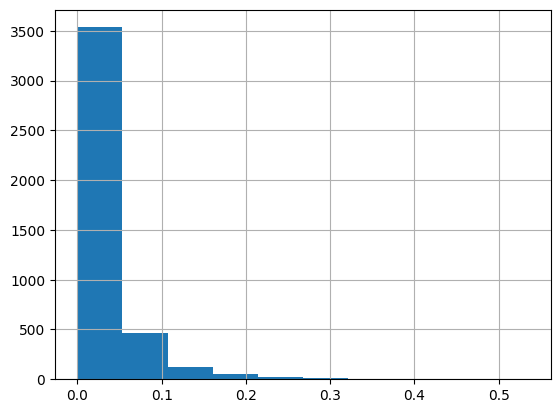

In [15]:
freq_sort['Support'].hist()

In [19]:
# 최소 지지도 설정 및 연관규칙 발견
# freq_items = apriori(df, min_support=0.001, use_colnames=True)
# sample_df = df.sample(frac=0.01, random_state=42)
# freq_items = apriori(sample_df, min_support=0.001, use_colnames=True)
# freq_items

# 메모리 초과로 다른 함수 사용............
from mlxtend.frequent_patterns import fpgrowth

freq_items = fpgrowth(df, min_support=0.01, use_colnames=True)
rules = association_rules(freq_items, metric="lift", min_threshold=1.0)
rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(ASSORTED COLOUR BIRD ORNAMENT),(WHITE HANGING HEART T-LIGHT HOLDER),0.059519,0.092449,0.013213,0.221993,2.401258,1.0,0.007710,1.166508,0.620482,0.095224,0.142741,0.182457
1,(WHITE HANGING HEART T-LIGHT HOLDER),(ASSORTED COLOUR BIRD ORNAMENT),0.092449,0.059519,0.013213,0.142920,2.401258,1.0,0.007710,1.097309,0.642996,0.095224,0.088680,0.182457
2,(ASSORTED COLOUR BIRD ORNAMENT),(REGENCY CAKESTAND 3 TIER),0.059519,0.081363,0.011045,0.185567,2.280730,1.0,0.006202,1.127947,0.597081,0.085066,0.113433,0.160657
3,(REGENCY CAKESTAND 3 TIER),(ASSORTED COLOUR BIRD ORNAMENT),0.081363,0.059519,0.011045,0.135747,2.280730,1.0,0.006202,1.088201,0.611279,0.085066,0.081052,0.160657
4,(HOME BUILDING BLOCK WORD),(WHITE HANGING HEART T-LIGHT HOLDER),0.031784,0.092449,0.010431,0.328185,3.549920,1.0,0.007493,1.350895,0.741884,0.091661,0.259750,0.220509


In [20]:
rules = association_rules(freq_items, metric="confidence", min_threshold=0.6)
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(POPPY'S PLAYHOUSE BEDROOM ),(POPPY'S PLAYHOUSE KITCHEN),0.017303,0.017835,0.012804,0.739953,41.488266,1.0,0.012495,3.776870,0.993081,0.573260,0.735230,0.728921
1,(POPPY'S PLAYHOUSE KITCHEN),(POPPY'S PLAYHOUSE BEDROOM ),0.017835,0.017303,0.012804,0.717890,41.488266,1.0,0.012495,3.483380,0.993618,0.573260,0.712922,0.728921
2,(ALARM CLOCK BAKELIKE GREEN),(ALARM CLOCK BAKELIKE RED ),0.040088,0.042993,0.026180,0.653061,15.190043,1.0,0.024457,2.758433,0.973181,0.460101,0.637475,0.631003
3,(ALARM CLOCK BAKELIKE RED ),(ALARM CLOCK BAKELIKE GREEN),0.042993,0.040088,0.026180,0.608944,15.190043,1.0,0.024457,2.454665,0.976134,0.460101,0.592612,0.631003
4,(ALARM CLOCK BAKELIKE PINK),(ALARM CLOCK BAKELIKE RED ),0.032030,0.042993,0.019226,0.600255,13.961793,1.0,0.017849,2.394047,0.959096,0.344575,0.582297,0.523724
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221,(GARDENERS KNEELING PAD CUP OF TEA ),(GARDENERS KNEELING PAD KEEP CALM ),0.031007,0.037348,0.022335,0.720317,19.286813,1.0,0.021177,3.441936,0.978491,0.485333,0.709466,0.659173
222,(JUMBO BAG VINTAGE CHRISTMAS ),(JUMBO BAG 50'S CHRISTMAS ),0.019471,0.029289,0.013172,0.676471,23.096369,1.0,0.012602,3.000379,0.975702,0.370115,0.666709,0.563096
223,(SET OF 12 MINI LOAF BAKING CASES),(SET OF 12 FAIRY CAKE BAKING CASES),0.018162,0.022580,0.012517,0.689189,30.521592,1.0,0.012107,3.144741,0.985129,0.443478,0.682009,0.621769
224,(SET OF 6 TEA TIME BAKING CASES),(SET OF 12 FAIRY CAKE BAKING CASES),0.015463,0.022580,0.010595,0.685185,30.344270,1.0,0.010246,3.104745,0.982233,0.385991,0.677912,0.577194


In [21]:
rules = rules[rules['lift'] > 1]
rules.sort_values(by='confidence', ascending=False)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
216,"(REGENCY TEA PLATE ROSES , REGENCY TEA PLATE P...",(REGENCY TEA PLATE GREEN ),0.011004,0.015585,0.010431,0.947955,60.823405,1.0,0.010260,18.914824,0.994502,0.645570,0.947131,0.808623
218,"(REGENCY TEA PLATE PINK, REGENCY TEA PLATE GRE...",(REGENCY TEA PLATE ROSES ),0.011372,0.018203,0.010431,0.917266,50.389863,1.0,0.010224,11.866933,0.991429,0.544872,0.915732,0.745150
212,(REGENCY TEA PLATE PINK),(REGENCY TEA PLATE GREEN ),0.012476,0.015585,0.011372,0.911475,58.482750,1.0,0.011178,11.120239,0.995319,0.681373,0.910074,0.820567
181,"(PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY...",(GREEN REGENCY TEACUP AND SAUCER),0.013540,0.041520,0.012313,0.909366,21.901823,1.0,0.011751,10.575228,0.967441,0.288038,0.905439,0.602959
185,"(PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY...",(GREEN REGENCY TEACUP AND SAUCER),0.024503,0.041520,0.022171,0.904841,21.792860,1.0,0.021154,10.072447,0.978079,0.505597,0.900719,0.719416
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,(CHRISTMAS CRAFT TREE TOP ANGEL),(CHRISTMAS CRAFT LITTLE FRIENDS),0.018694,0.022253,0.011290,0.603939,27.139497,1.0,0.010874,2.468676,0.981502,0.380690,0.594925,0.555646
190,"(LUNCH BAG CARS BLUE, LUNCH BAG SUKI DESIGN )",(LUNCH BAG BLACK SKULL.),0.019267,0.052074,0.011617,0.602972,11.579154,1.0,0.010614,2.387557,0.931587,0.194521,0.581162,0.413034
162,(POPPY'S PLAYHOUSE KITCHEN),(POPPY'S PLAYHOUSE LIVINGROOM ),0.017835,0.013417,0.010717,0.600917,44.786669,1.0,0.010478,2.472127,0.995426,0.521912,0.595490,0.699849
4,(ALARM CLOCK BAKELIKE PINK),(ALARM CLOCK BAKELIKE RED ),0.032030,0.042993,0.019226,0.600255,13.961793,1.0,0.017849,2.394047,0.959096,0.344575,0.582297,0.523724
